In [1]:
# 1 Частина
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
df = pd.read_csv("loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [4]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean["Loan_Status"] = df_clean["Loan_Status"].map({"N": 0, "Y": 1})

In [5]:
X = df_clean.drop(columns=["Loan_ID", "Loan_Status"])
y = df_clean["Loan_Status"]

X = pd.get_dummies(X, drop_first=True)

print("Final feature shape:", X.shape)

Final feature shape: (381, 14)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(304, 14) (77, 14)


In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)

X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test.values,  dtype=torch.long)

In [9]:
train_data = TensorDataset(X_train, y_train)
test_data  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

In [10]:
class LoanMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

In [11]:
model = LoanMLP(input_dim=X_train.shape[1]).to(device)
print(model)

LoanMLP(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [13]:
n_epochs = 20

train_loss_history = []
val_loss_history = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

[01] train_loss=0.6480 | val_loss=0.6208
[02] train_loss=0.6067 | val_loss=0.5802
[03] train_loss=0.5672 | val_loss=0.5435
[04] train_loss=0.5400 | val_loss=0.5058
[05] train_loss=0.5052 | val_loss=0.4711
[06] train_loss=0.4757 | val_loss=0.4375
[07] train_loss=0.4362 | val_loss=0.4091
[08] train_loss=0.4146 | val_loss=0.3866
[09] train_loss=0.4099 | val_loss=0.3687
[10] train_loss=0.3942 | val_loss=0.3608
[11] train_loss=0.3757 | val_loss=0.3533
[12] train_loss=0.3596 | val_loss=0.3492
[13] train_loss=0.3586 | val_loss=0.3481
[14] train_loss=0.3604 | val_loss=0.3469
[15] train_loss=0.3543 | val_loss=0.3478
[16] train_loss=0.3442 | val_loss=0.3475
[17] train_loss=0.3325 | val_loss=0.3445
[18] train_loss=0.3366 | val_loss=0.3466
[19] train_loss=0.3368 | val_loss=0.3507
[20] train_loss=0.3358 | val_loss=0.3483


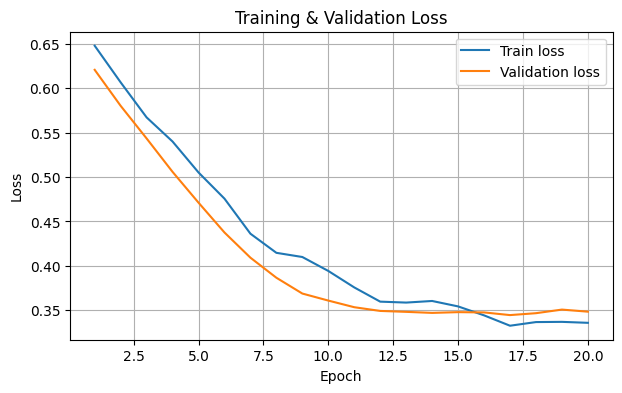

In [14]:
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, train_loss_history, label="Train loss")
plt.plot(epochs, val_loss_history, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [15]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())

print("Accuracy:", accuracy_score(all_true, all_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds, digits=4))

Accuracy: 0.8441558441558441

Confusion Matrix:
[[11 11]
 [ 1 54]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9167    0.5000    0.6471        22
           1     0.8308    0.9818    0.9000        55

    accuracy                         0.8442        77
   macro avg     0.8737    0.7409    0.7735        77
weighted avg     0.8553    0.8442    0.8277        77



У лабораторній 1 найкращу точність показав алгориитм Random Forest. Нейронна модель показала трішки гірші резульати, але забезпечила кращу узагальнювальну здатність для класу 1.
З цього зрозуміло, що класичні алгоритми ефективніші на малих вибірках, тоді як нейронні мережі краще працюють на великих вибірках, особливо текстовиих.

In [16]:
#2 Частина
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [17]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("techsash/waste-classification-data")
print("Dataset path:", path)
DATASET_ROOT = "/kaggle/input/waste-classification-data/DATASET"

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset path: /kaggle/input/waste-classification-data


In [18]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [19]:
from torchvision import datasets
from torch.utils.data import DataLoader
DATASET_ROOT = os.path.join(path, "DATASET")
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_ROOT, "TRAIN"),
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_ROOT, "TEST"),
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Класи:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Класи: ['O', 'R']
Train size: 22564
Test size: 2513


In [20]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

cnn_model = SimpleCNN().to(device)
print(cnn_model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

epochs = 5
cnn_start = time.time()

for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"[CNN] Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

cnn_time = time.time() - cnn_start

[CNN] Epoch 1/5, Loss: 0.4129
[CNN] Epoch 2/5, Loss: 0.3364
[CNN] Epoch 3/5, Loss: 0.2980
[CNN] Epoch 4/5, Loss: 0.2694
[CNN] Epoch 5/5, Loss: 0.2335


In [22]:
cnn_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_acc = correct / total
print("Simple CNN accuracy:", cnn_acc)

Simple CNN accuracy: 0.88141663350577


In [23]:
resnet = models.resnet18(pretrained=True)

for param in resnet.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.001)

epochs = 5
resnet_start = time.time()

for epoch in range(epochs):
    resnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"[ResNet] Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

resnet_time = time.time() - resnet_start

[ResNet] Epoch 1/5, Loss: 0.2477
[ResNet] Epoch 2/5, Loss: 0.2056
[ResNet] Epoch 3/5, Loss: 0.2015
[ResNet] Epoch 4/5, Loss: 0.1990
[ResNet] Epoch 5/5, Loss: 0.1959


In [26]:
resnet.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

resnet_acc = correct / total
print("ResNet accuracy:", resnet_acc)

ResNet accuracy: 0.9025069637883009


In [27]:
print("\n===== Порівняння =====")
print(f"Simple CNN → Accuracy: {cnn_acc:.3f}, Time: {cnn_time:.1f}s")
print(f"ResNet18  → Accuracy: {resnet_acc:.3f}, Time: {resnet_time:.1f}s")


===== Порівняння =====
Simple CNN → Accuracy: 0.881, Time: 536.3s
ResNet18  → Accuracy: 0.903, Time: 462.9s


Проста CNN модель показала accuracy = 0.881, тоді як ResNet18 — 0.903. ResNet18 показала вищу точність і менший час навчання, що пояснюється використанням попередньо навчених ваг та глибшої архітектури.


In [28]:
# 3 Частина
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df[["text", "label"]]
df.dropna(inplace=True)

df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [30]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df["text"] = df["text"].apply(clean_text)

In [31]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN = 300

def build_vocab(texts):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(MAX_VOCAB))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

X_train, X_test, y_train, y_test = train_test_split(
    df["text"].values, df["label"].values, test_size=0.2, random_state=42
)
vocab = build_vocab(X_train)

In [32]:
def encode(text, vocab):
    tokens = text.split()[:MAX_LEN]
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    return ids + [0] * (MAX_LEN - len(ids))

In [33]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(encode(self.texts[idx], vocab)),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

train_ds = NewsDataset(X_train, y_train)
test_ds = NewsDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [34]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1]).squeeze()

In [35]:
def train_model(model, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        losses = []

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        print(f"Epoch {epoch+1}: loss={np.mean(losses):.4f}")

In [36]:
model_random = LSTMClassifier(len(vocab)).to(device)
train_model(model_random)

Epoch 1: loss=0.6005
Epoch 2: loss=0.5054
Epoch 3: loss=0.4290
Epoch 4: loss=0.3871
Epoch 5: loss=0.1770


In [37]:
def evaluate(model):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device)
            p = torch.sigmoid(model(X))
            preds.extend((p > 0.5).int().tolist())
            true.extend(y.tolist())

    return accuracy_score(true, preds)

acc_random = evaluate(model_random)
print("Accuracy (random embedding):", acc_random)

Accuracy (random embedding): 0.967706013363029


In [38]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-01-04 23:22:24--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-01-04 23:22:24--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-01-04 23:22:24--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [39]:
EMB_DIM = 100
embeddings = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype=np.float32)
        embeddings[word] = vec

embedding_matrix = np.random.normal(
    scale=0.1, size=(len(vocab), EMB_DIM)
).astype(np.float32)

embedding_matrix[vocab["<PAD>"]] = 0.0

for word, idx in vocab.items():
    if word in embeddings:
        embedding_matrix[idx] = embeddings[word]

In [40]:
class LSTMGlove(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=0
        )
        self.lstm = nn.LSTM(EMB_DIM, 128, batch_first=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1]).squeeze()

In [41]:
model_glove = LSTMGlove(embedding_matrix).to(device)
train_model(model_glove)

Epoch 1: loss=0.5207
Epoch 2: loss=0.3474
Epoch 3: loss=0.1931
Epoch 4: loss=0.0455
Epoch 5: loss=0.0106


In [42]:
acc_glove = evaluate(model_glove)

print("Accuracy random embedding:", acc_random)
print("Accuracy GloVe embedding:", acc_glove)

Accuracy random embedding: 0.967706013363029
Accuracy GloVe embedding: 0.998218262806236


Модель з випадковою ініціалізацією embedding показала accuracy = 0.968, тоді як використання GloVe embedding підвищило точність до 0.998. відповідно до результатів, що ми бачимо зрозуміло, що попередньо навчені векторні подання слів покращують якість класифікації.